In [1]:

# HOUSE RENT PREDICTION USING LINEAR REGRESSION
# -----------------------------------------------------------
# Project : End-to-End ML Regression Project
# Goal    : Predict house rent 

In [2]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Statistical Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Metrics
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)

# Ignore Warnings

import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Plot Styling

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

In [4]:
# Load Dataset

df = pd.read_csv("House_Rent_Dataset.csv")

In [5]:
# Dataset Shape

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 4746
Number of Columns : 12


In [6]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [8]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BHK,4746.0,2.083860,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Bathroom,4746.0,1.965866,0.884532,1.0,1.0,2.0,2.0,10.0


In [10]:
df.describe(include="all")

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
count,4746,4746.000000,4.746000e+03,4746.000000,4746,4746,4746,4746,4746,4746,4746.000000,4746
unique,81,NaN,NaN,NaN,480,3,2235,6,3,3,NaN,3
top,2022-07-06,NaN,NaN,NaN,1 out of 2,Super Area,Bandra West,Mumbai,Semi-Furnished,Bachelors/Family,NaN,Contact Owner
freq,311,NaN,NaN,NaN,379,2446,37,972,2251,3444,NaN,3216
mean,NaN,2.083860,3.499345e+04,967.490729,NaN,NaN,NaN,NaN,NaN,NaN,1.965866,NaN
std,NaN,0.832256,7.810641e+04,634.202328,NaN,NaN,NaN,NaN,NaN,NaN,0.884532,NaN
min,NaN,1.000000,1.200000e+03,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,2.000000,1.000000e+04,550.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
50%,NaN,2.000000,1.600000e+04,850.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN
75%,NaN,3.000000,3.300000e+04,1200.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN


In [11]:
# checking nulls 
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [12]:
# Duplicates
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [13]:
print(list(df.columns))

['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']


In [14]:
# Droping Columns
df = df.drop(columns=["Floor","Area Locality","Posted On"])
df.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [15]:
# Reset index
df = df.reset_index(drop=True)

In [16]:
df.dtypes

BHK                   int64
Rent                  int64
Size                  int64
Area Type            object
City                 object
Furnishing Status    object
Tenant Preferred     object
Bathroom              int64
Point of Contact     object
dtype: object

In [17]:
# Numerical Columns
numerical_columns = df.select_dtypes(include=np.number).columns

print(list(numerical_columns))

['BHK', 'Rent', 'Size', 'Bathroom']


In [18]:
# Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns

print(list(categorical_columns))

['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']


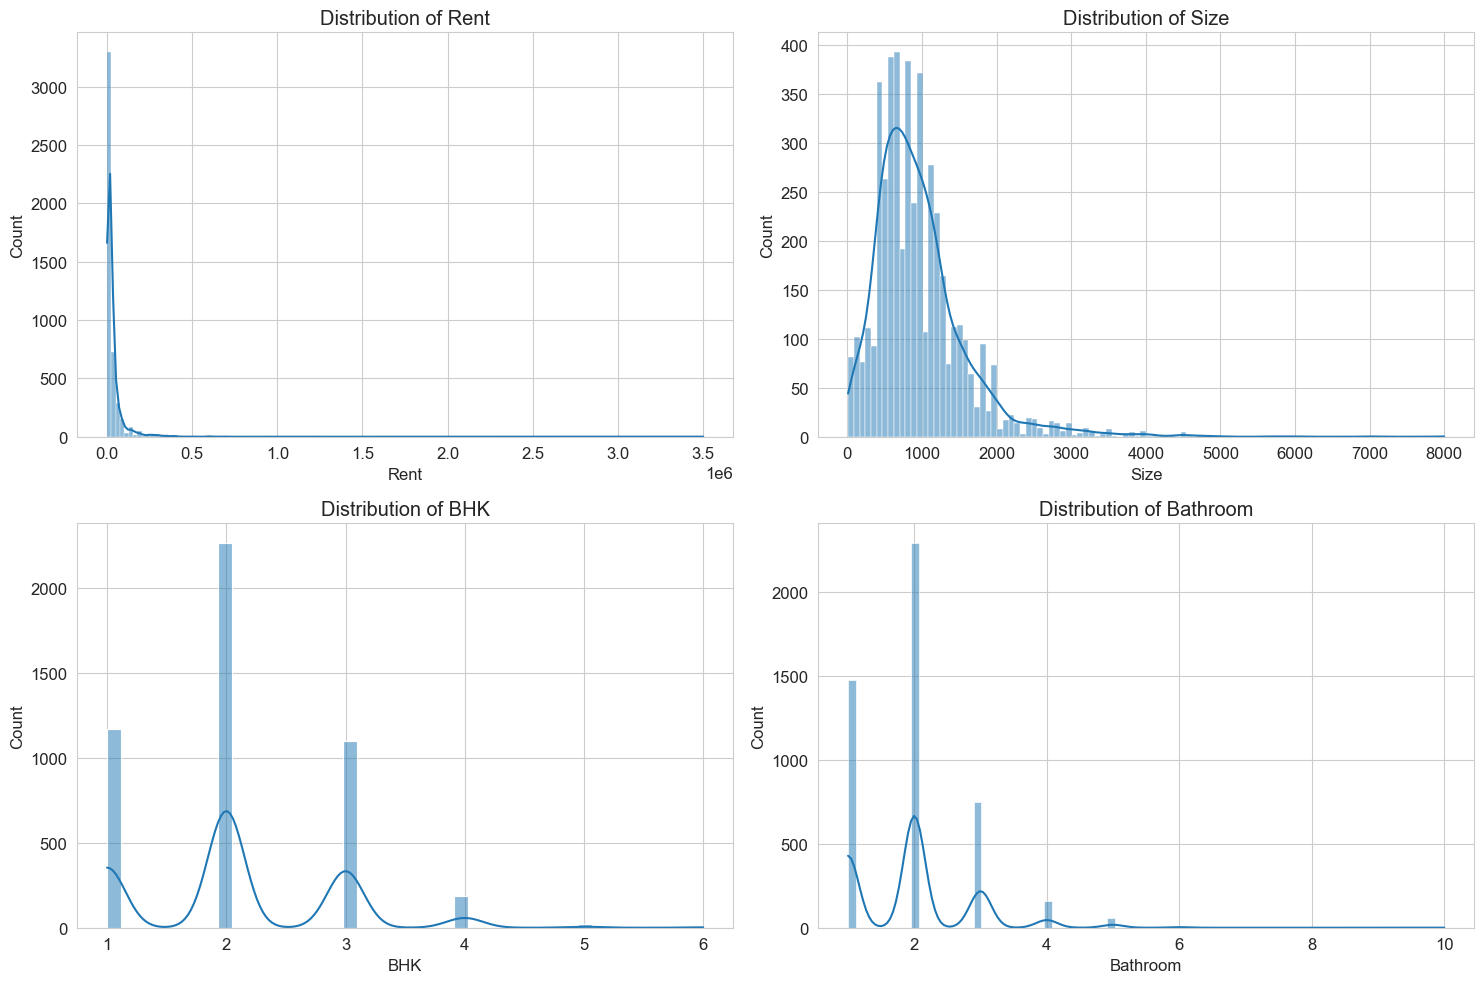

In [19]:
# Numerical Distribution
numerical_columns = ['Rent','Size','BHK','Bathroom']

plt.figure(figsize=(15,10))

for i, column in enumerate(numerical_columns, 1):
    
    plt.subplot(2,2,i)
    
    sns.histplot(df[column],kde=True)
    
    plt.title(f'Distribution of {column}')

plt.tight_layout()

plt.show()

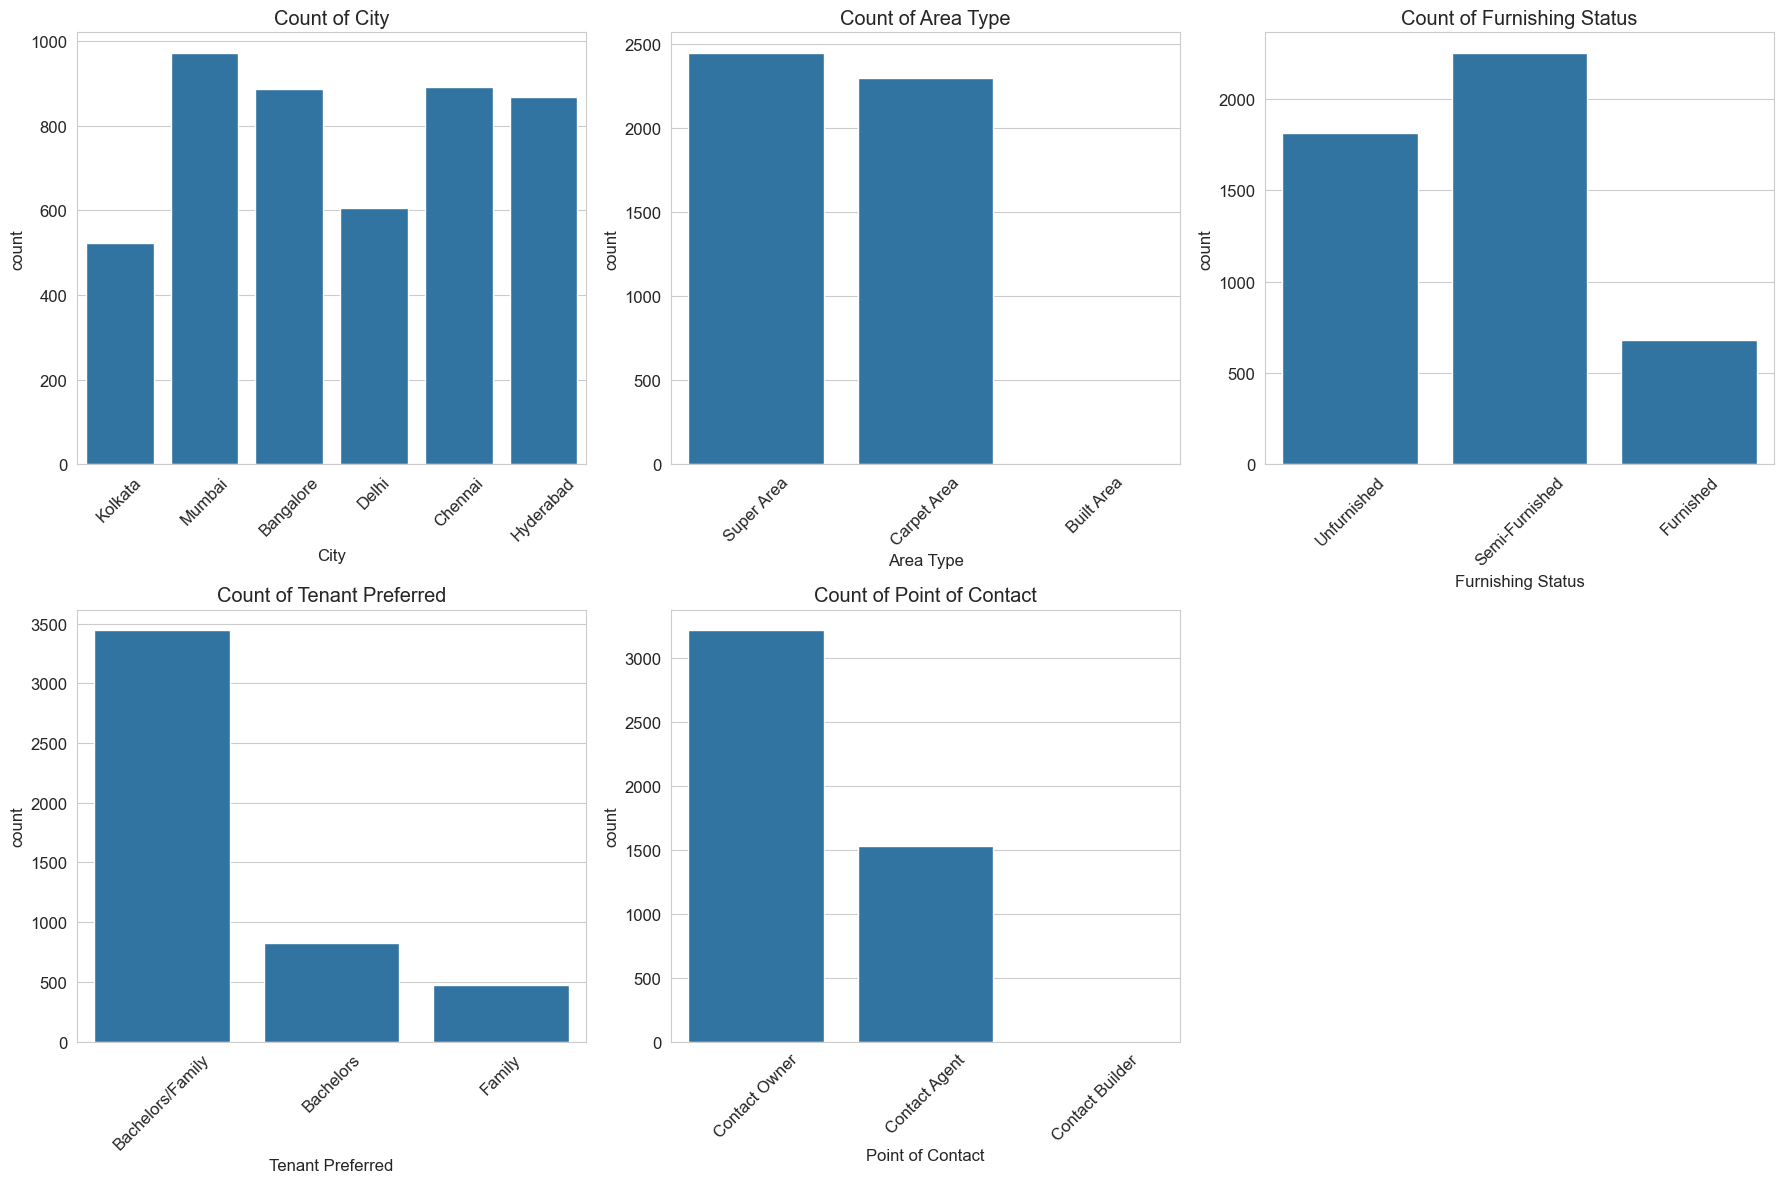

In [20]:
# Categorical DISTRIBUTIONS
categorical_columns = ['City','Area Type','Furnishing Status','Tenant Preferred','Point of Contact']

plt.figure(figsize=(18,12))

for i, column in enumerate(categorical_columns, 1):
    
    plt.subplot(2,3,i)
    
    sns.countplot(x=df[column])
    
    plt.title(f'Count of {column}')
    
    plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

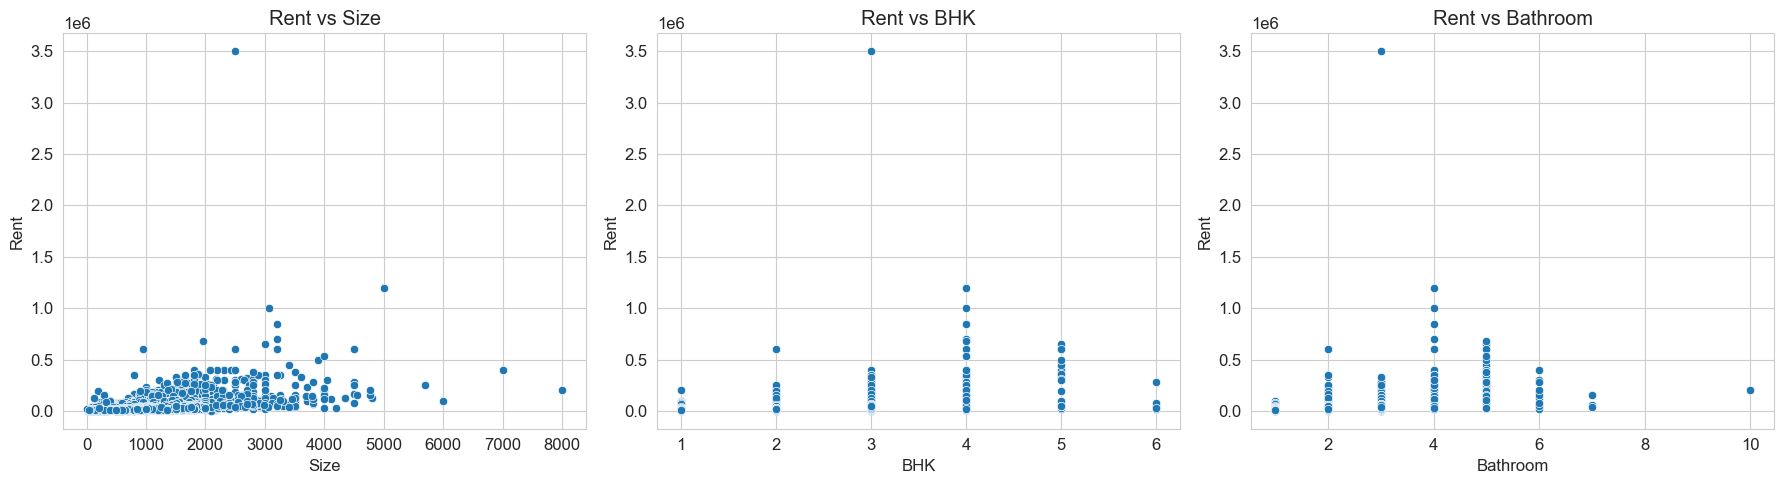

In [21]:
# Rent Vs Numerical Features
features = ['Size','BHK','Bathroom']

plt.figure(figsize=(18,5))

for i, column in enumerate(features, 1):
    
    plt.subplot(1,3,i)
    
    sns.scatterplot(x=df[column],y=df['Rent'])
    plt.title(f'Rent vs {column}')

plt.tight_layout()

plt.show()

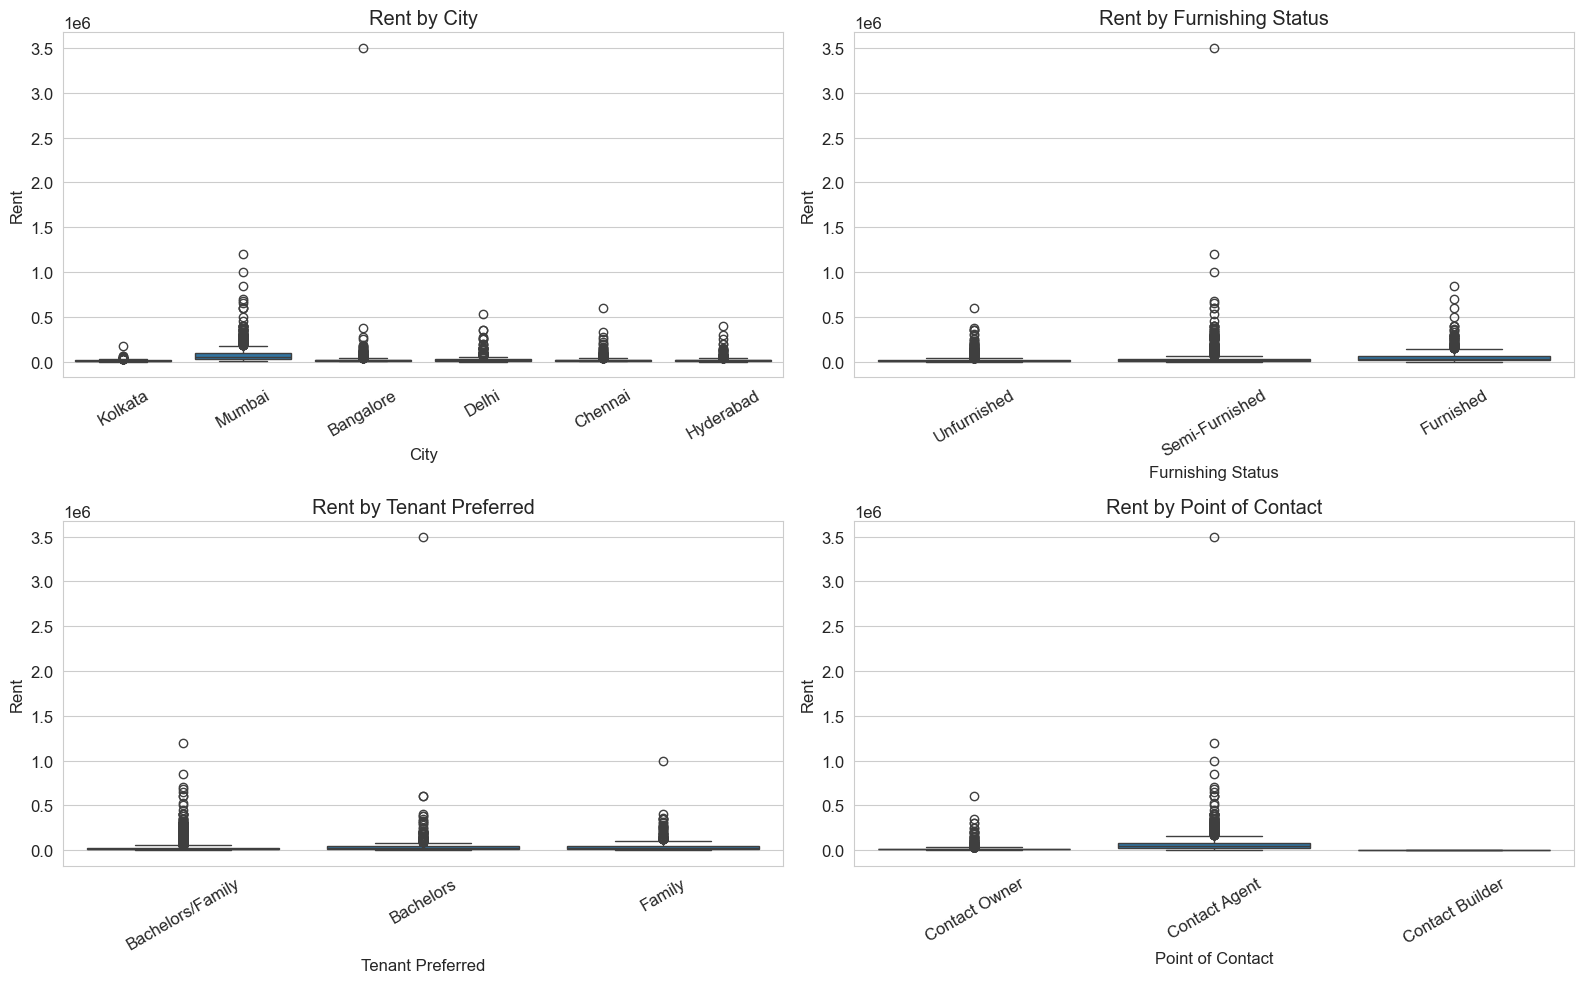

In [22]:
#Rent vs Categorical Feature
# =============================================================================

cat_features = ['City','Furnishing Status','Tenant Preferred','Point of Contact']

fig, axes = plt.subplots(2, 2, figsize=(16,10))

for i, col in enumerate(cat_features):

    ax = axes[i//2][i%2]

    sns.boxplot(x=df[col],y=df['Rent'],ax=ax)

    ax.set_title(f'Rent by {col}')

    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.show()


In [23]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,BHK,Rent,Size,Bathroom
BHK,1.000000,0.369718,0.716145,0.794885
Rent,0.369718,1.000000,0.413551,0.441215
Size,0.716145,0.413551,1.000000,0.740703
Bathroom,0.794885,0.441215,0.740703,1.000000


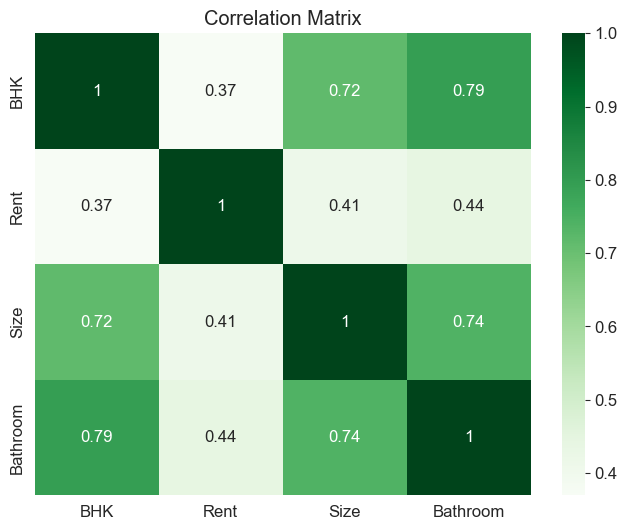

In [24]:
# CORRELATION MATRIX
# --------------------------------
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap="Greens")

plt.title("Correlation Matrix")

plt.show()

In [25]:
# Outlier Treatment Rent
# ------------------------------------------
rent_upper_limit = df["Rent"].quantile(0.99)

df = df[df["Rent"] < rent_upper_limit]

print("Outliers Removed from Rent")

Outliers Removed from Rent


In [26]:
# Outlier Treatment Size
size_upper_limit = df["Size"].quantile(0.99)

df = df[df["Size"] < size_upper_limit]

print("Outliers Removed from Size")

Outliers Removed from Size


In [27]:
print("\nShape After Outlier Removal :", df.shape)


Shape After Outlier Removal : (4646, 9)


In [28]:
df = df.reset_index(drop=True)

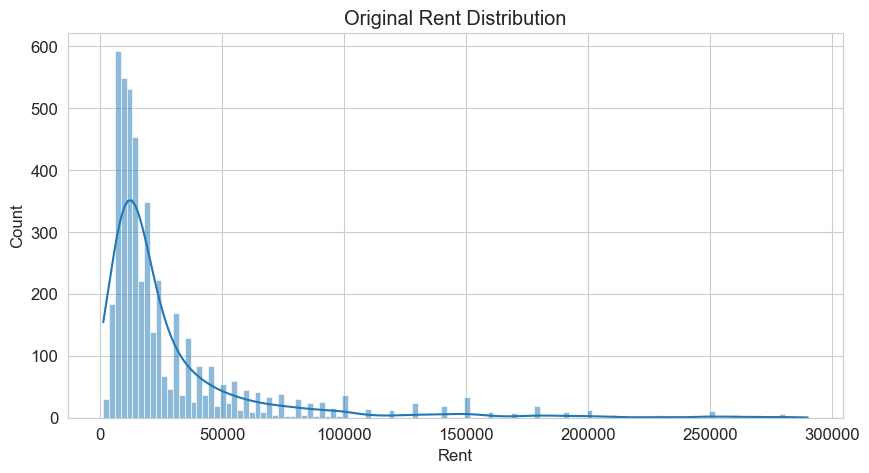

In [29]:
# Original Rent Distribution
sns.histplot(df["Rent"],kde=True)

plt.title("Original Rent Distribution")

plt.show()

In [30]:
# Log Transformation
df["log_rent"] = np.log(df["Rent"])

In [31]:
# Original Rent Distribution 
# And 
# Log Transformed Rent

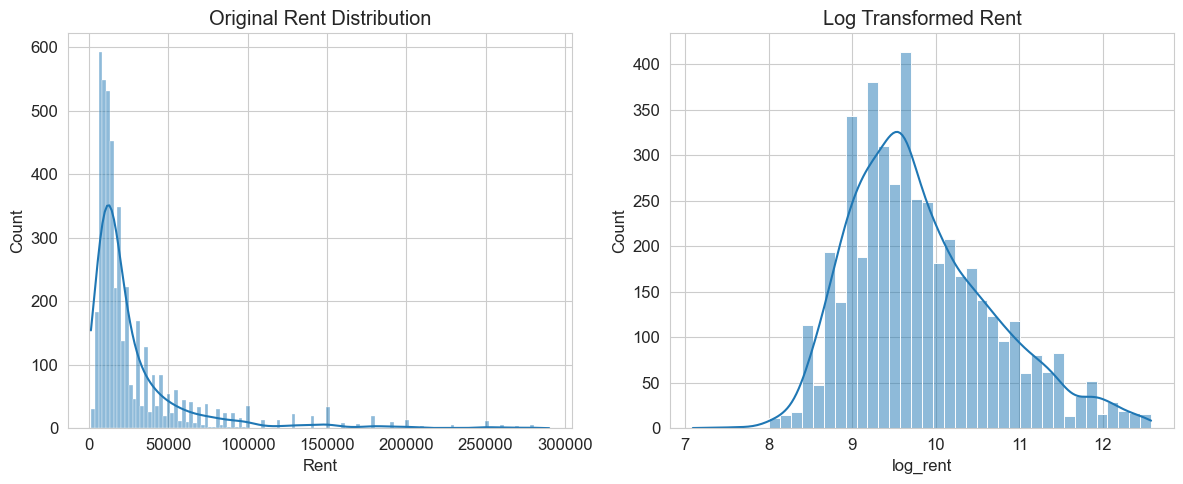

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot( df['Rent'],kde=True)

plt.title('Original Rent Distribution')

plt.subplot(1,2,2)

sns.histplot(df['log_rent'],kde=True)

plt.title('Log Transformed Rent')

plt.tight_layout()

plt.show()

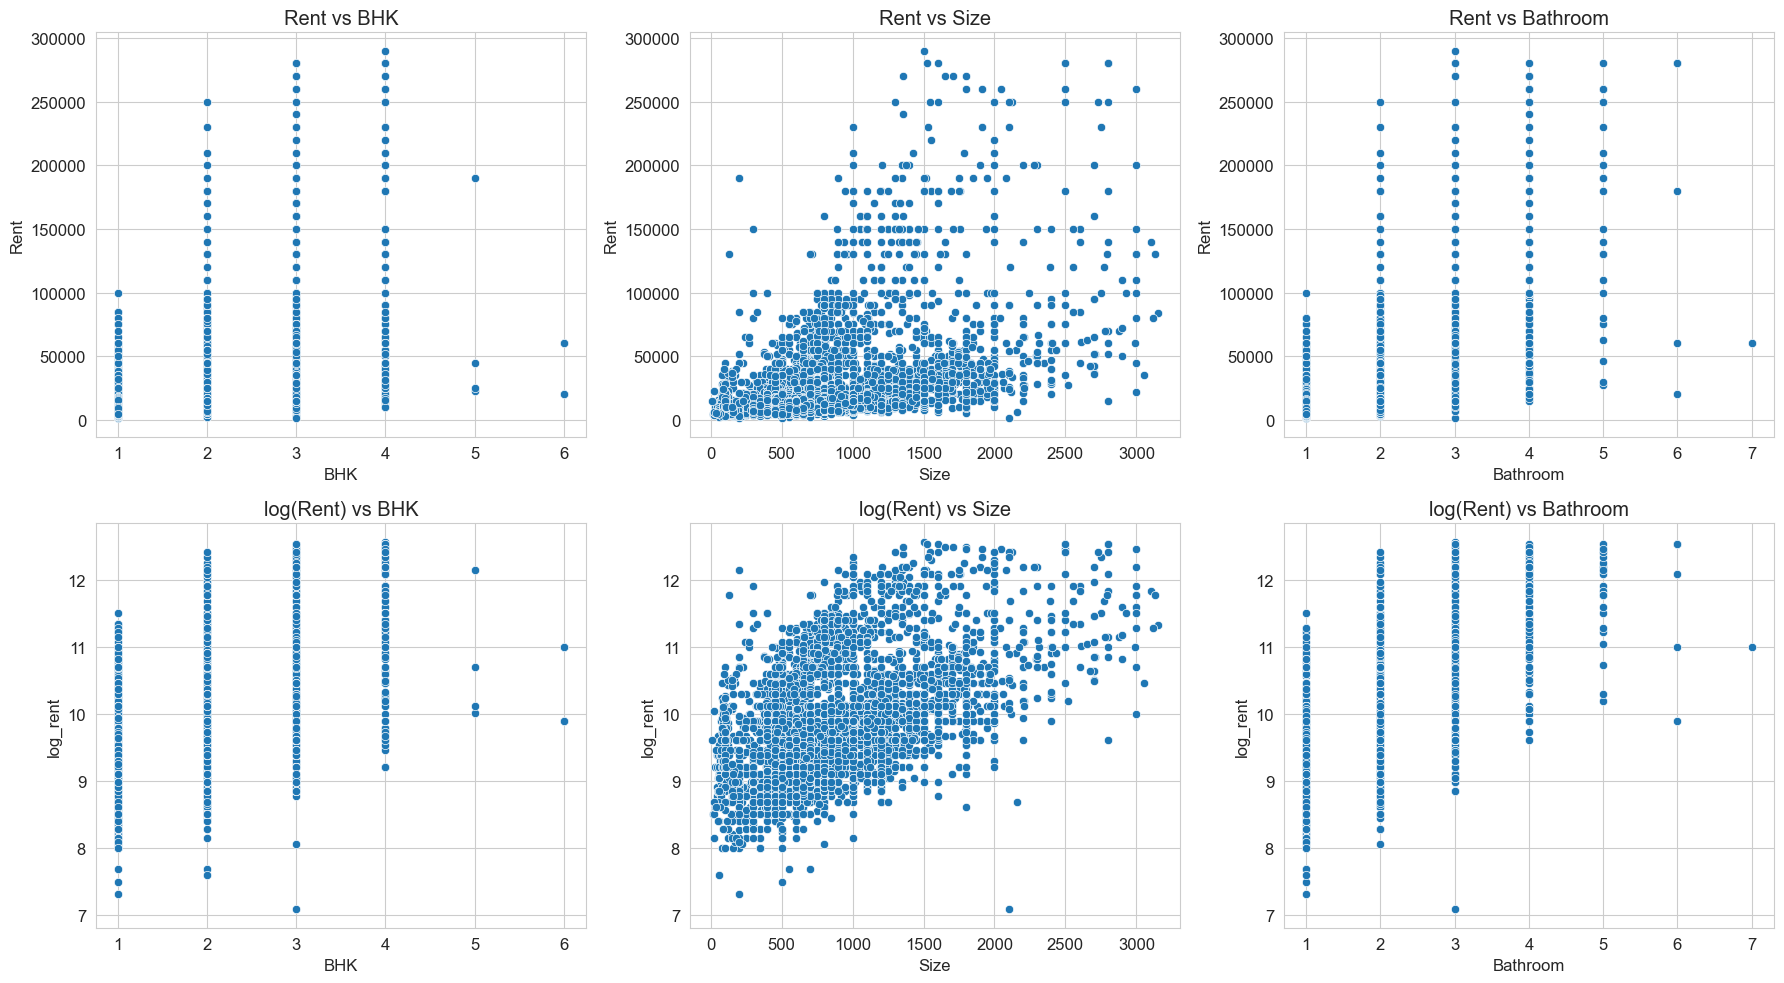

In [33]:
# Linearity Check

fig, axes = plt.subplots(2, 3, figsize=(18,10))

features = ['BHK', 'Size', 'Bathroom']

for i, col in enumerate(features):

    sns.scatterplot(x=df[col],y=df['Rent'],ax=axes[0][i])

    axes[0][i].set_title(f'Rent vs {col}')

    sns.scatterplot(x=df[col],y=df['log_rent'],ax=axes[1][i])

    axes[1][i].set_title(f'log(Rent) vs {col}')

plt.tight_layout()

plt.show()

In [34]:
# Removed Orginal Rent
df = df.drop(columns=["Bathroom"])

In [35]:

vif_data = df[["BHK","Size"]]

vif_df = pd.DataFrame()

vif_df["Feature"] = vif_data.columns

vif_df["VIF"] = [variance_inflation_factor(vif_data.values,i)
    for i in range(vif_data.shape[1])]

vif_df

,Feature,VIF
0,BHK,8.521561
1,Size,8.521561


In [36]:

df = df.drop(columns=["Rent"])

In [37]:
# Dummy Encoding 
df = pd.get_dummies(df,drop_first=True, dtype=int)

df.head()

,BHK,Size,log_rent,Area Type_Carpet Area,Area Type_Super Area,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,2,1100,9.210340,0,1,0,0,0,1,0,0,1,1,0,0,1
1,2,800,9.903488,0,1,0,0,0,1,0,1,0,1,0,0,1
2,2,1000,9.740969,0,1,0,0,0,1,0,1,0,1,0,0,1
3,2,800,9.210340,0,1,0,0,0,1,0,0,1,1,0,0,1
4,2,850,8.922658,1,0,0,0,0,1,0,0,1,0,0,0,1


In [38]:
# INPUTS AND TARGET
X = df.drop(columns=["log_rent"])

y = df["log_rent"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split( X,y,  test_size=0.2, random_state=42)
print("\nTraining Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)


Training Shape : (3716, 15)
Testing Shape : (930, 15)


In [40]:
# Feature Scaling

numerical_columns = ["BHK", "Size"]

scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)


In [41]:
# MODEL BUILDING
model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")



Model Training Completed


In [42]:
# Predection 
y_train_pred = model.predict(X_train)

In [43]:
# Training R2 Score

train_r2 = r2_score(y_train,y_train_pred)

print("Training R2 Score :", train_r2)

Training R2 Score : 0.7862252234218453


In [44]:
# Test PREDICTIONS
test_predictions = model.predict(X_test)

In [45]:
# MODEL EVALUATION
r2 = r2_score(y_test, test_predictions)

mae = mean_absolute_error(y_test, test_predictions)

rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print("\nR2 Score :", round(r2, 4))

print("MAE :", round(mae, 4))

print("RMSE :", round(rmse, 4))



R2 Score : 0.815
MAE : 0.2974
RMSE : 0.3864


In [46]:
# Actual vs Predicted

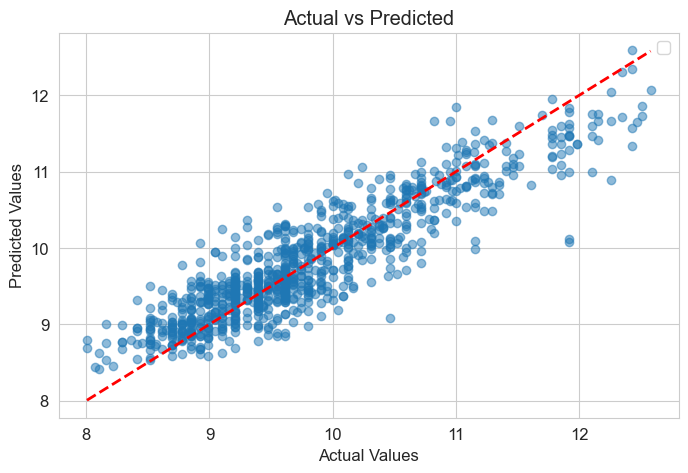

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, test_predictions, alpha=0.5)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linestyle="--",linewidth=2,)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.legend()

plt.show()

In [48]:
# # RESIDUAL ANALYSIS
residuals = y_test - test_predictions

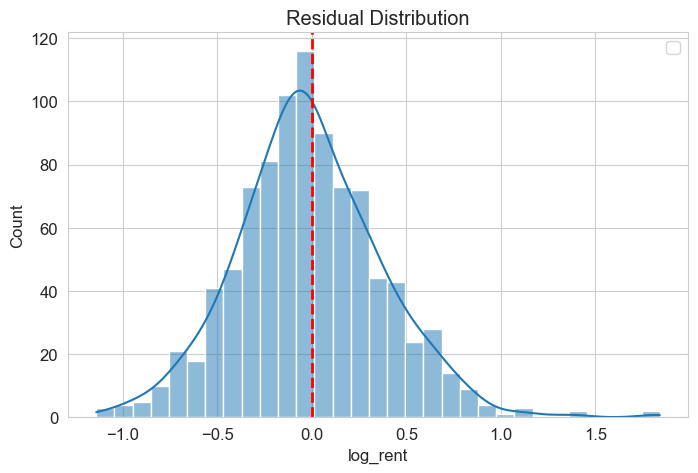

In [49]:


# Residual Distribution

plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.axvline(x=0,color="red",linestyle="--",linewidth=2,)

plt.title("Residual Distribution")

plt.legend()

plt.show()

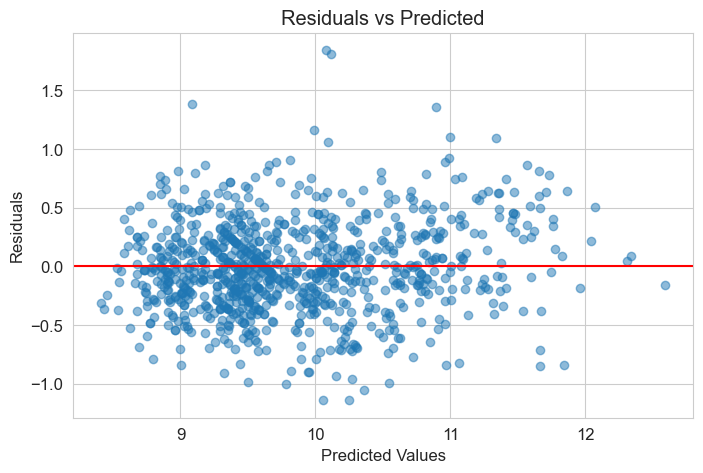

In [50]:
# Residual Scatter Plot

plt.figure(figsize=(8, 5))

plt.scatter(test_predictions, residuals, alpha=0.5)

plt.axhline(0, color="red")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Predicted")

plt.show()

In [51]:
# DURBIN WATSON TEST
dw_score = durbin_watson(residuals)

print("\nDurbin Watson Score :", round(dw_score, 4))


Durbin Watson Score : 2.0382


In [52]:
# REVERSE LOG TRANSFORMATION
actual_rent = np.expm1(y_test)

predicted_rent = np.expm1(test_predictions)

comparison_df = pd.DataFrame({
    "Actual Rent": actual_rent,
    "Predicted Rent": predicted_rent
})

comparison_df["Difference"] = (
    comparison_df["Actual Rent"] -
    comparison_df["Predicted Rent"]
)

print("\nComparison Table :")

print(comparison_df.head())



Comparison Table :
      Actual Rent  Predicted Rent    Difference
1467      14999.0    21665.021803  -6666.021803
1803      18499.0    19274.808548   -775.808548
2821      27999.0    63818.838936 -35819.838936
230       17999.0     7976.282493  10022.717507
3829       8999.0    11598.375565  -2599.375565


In [53]:
# SAVE MODEL
joblib.dump(model, "house_rent_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("\nModel Saved Successfully")


Model Saved Successfully


In [54]:
sample_data = pd.DataFrame({
    "BHK": [2],
    "Size": [1200],
    "Posted On": ["2022-05-18"],
    "Area Type": ["Super Area"],
    "City": ["Mumbai"],
    "Furnishing Status": ["Semi-Furnished"],
    "Tenant Preferred": ["Bachelors/Family"],
    "Point of Contact": ["Contact Owner"]
})

sample_data = pd.get_dummies(sample_data)

sample_data = sample_data.reindex(
    columns=X.columns,
    fill_value=0
)

sample_data[numerical_columns] = scaler.transform(
    sample_data[numerical_columns]
)

sample_prediction = model.predict(sample_data)

predicted_rent = np.expm1(sample_prediction)

print("\nPredicted Rent :", round(predicted_rent[0], 2))


Predicted Rent : 43353.11


In [55]:
# END OF CODE